# Visualizing the Rotational Profile of Butane

We can use the data produced in the scan of bond angles from the previous notebook. There we set the central torsional angle to some value and optimized the structure for that angle. the energies for each angle were collected in a csv file along with the angle and optimized structure. We can now use the data, stored in a csv file, to interpret the results. Do not run the calculation again unless you have some time to spare.

## Setup

Below we set the information to access the files. use the same `basename` and `runname` as you used to generate the data in the previous notebook.

In [17]:
# Initial Information

basename = "butane_scan" 
runname = "hf-631G-previous" 

## Plot the Data

The plot below presents the relative energies of the optimized structure against the corresponding central torsional angle.

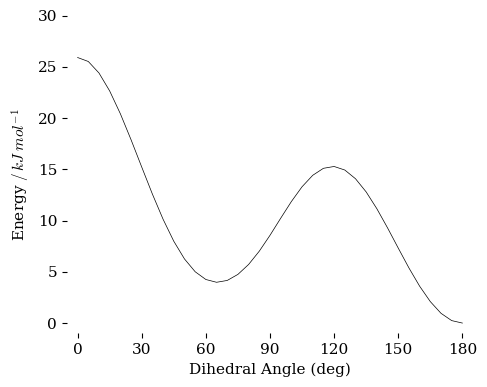

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

styles_location = "../../../styles/"
plt.rcParamsDefault
plt.style.use(styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

df = pd.read_csv(f"{basename}_{runname}.csv")

ax.plot(df["Dihedral Angle (deg)"], df["Energy (kJ/mol)"], marker=None, linewidth=0.5
        )
ax.set_xlabel("Dihedral Angle (deg)")
ax.set_ylabel(r"Energy $/\,kJ\; mol^{-1}$")
ax.set_xlim(-5, 185)
ax.set(xticks=[0, 30, 60, 90, 120, 150, 180])
ax.set_ylim(-1, 30)
#ax.set(yticks=[0, 5, 10, 15, 20, 25])
#ax.set_title("Butane Rotation Profile")
#plt.grid()
plt.savefig(f"{basename}_{runname}2.pdf", bbox_inches='tight')
plt.show()


## Plot the Data Again

The plot below presents the relative energies of the optimized structure against the corresponding central torsional angle. The style is different and this is the version used in the textbook.

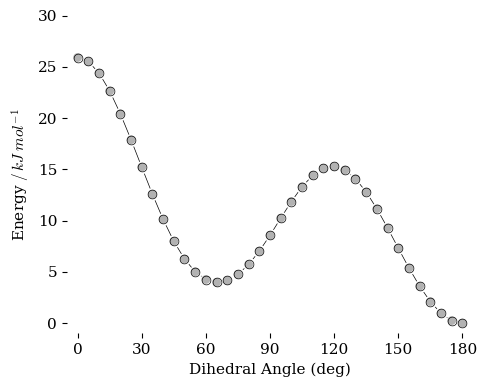

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

styles_location = "../../../styles/"
plt.rcParamsDefault
plt.style.use(styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

df = pd.read_csv(f"{basename}_{runname}.csv")

x = df["Dihedral Angle (deg)"]
y = df["Energy (kJ/mol)"]

s=40
ax.scatter(x, y, marker='o', s=s, facecolor='white', edgecolors='white', linewidth=3, alpha=1  )
ax.scatter(x, y, marker='o', s=s, facecolor='white', edgecolors='black', linewidth=0.5, alpha=1  )
ax.scatter(x, y, marker='o', s=s, facecolor='black', edgecolors='none', alpha=0.3  )

ax.plot(x, y, 
        marker=None, 
        linewidth=0.5,
        zorder=-3)
ax.set(ylim=(-1, 30),
       xlim=(-5, 185),
       xticks=[0, 30, 60, 90, 120, 150, 180],
       xlabel="Dihedral Angle (deg)",
       ylabel=r"Energy $/\,kJ\; mol^{-1}$",
       title="",
        )#plt.grid()
plt.savefig(f"{basename}_{runname}.pdf", bbox_inches='tight')
plt.show()



## Collect the Structures

Here we collect the structures from the data set put them in an array to be used in an interactive display below.

In [20]:
# --- Retrieve Psi4 molecules to XYZ strings ---

molecules = df["xyz"].tolist() # Get the list of Psi4 molecule objects from the dataframe

xyz_strings = [] # This will hold the XYZ strings for each molecule
for mol in molecules:
    lines = mol.splitlines()
    number_atoms = len(lines) - 1 # The first line of the XYZ string from Psi4 is charge and multiplicity info, so we subtract 1 from the total number of lines to get the number of atoms.
    xyz_string = "\n".join([str(number_atoms), ""] + lines[1:]) # Create a new XYZ string with the correct format: first line is number of atoms, second line is blank (can be a name or comment), and the rest are the atom lines from the original XYZ string (skipping the first line).
    xyz_strings.append(xyz_string) # Add the formatted XYZ string to the list

print(xyz_strings[0]) # Display the first XYZ string to check the format

14

 C   -0.000015599082    1.012191901279   -1.256787868624
 C   -0.000015599082    1.012191901279    0.274639823584
 C   -0.000015599082   -0.374274372988    0.979804582632
 C   -0.000006828039   -1.611703957402    0.077798377789
 H   -0.016420146261    2.033401392018   -1.625567356702
 H   -0.868397294514    0.505357997301   -1.664344092417
 H    0.884581465290    0.533442330683   -1.663915998776
 H    0.863728505020    1.577846820410    0.611951055703
 H   -0.865848499525    1.575845838356    0.610045673475
 H    0.865781128175   -0.435966008778    1.632788923981
 H   -0.863663826540   -0.435265072839    1.635712428310
 H   -0.879969219735   -1.654441084327   -0.555541952514
 H    0.873372737058   -1.645940111424   -0.564909424363
 H    0.007473658108   -2.511569478952    0.685351992658


## Visualize the Structures

Below is code that will produce an image of the structure using the $xyz$ cartessian coordinates and present them in an interactive display that includes an image of the structure, the relative energy and the torsional angle. Move the slider and see how energy relates to structure.

```{note}
:class: dropdown
This will work only if you run the code in a Jupyter notebook. It does not use html and can't be displayed as a static object. If you are running this code yourself, the initial output of the display may be an error message. Move the slider and the widget will start working (at least that's how it works with my computer).
```

In [21]:
import py3Dmol
import ipywidgets as widgets
from IPython.display import display
from ipywidgets import interact, interactive, fixed

# --- Viewer function ---

angles = df["Dihedral Angle (deg)"].tolist()

def show_molecule(i):
    xyz = xyz_strings[i]
    energy = energies_array[i]
    angle = angles[i]
    print(f"Structure: {i}, Energy: {energy:.2f} kJ/mol, Dihedral Angle: {angle:.2f} deg")

    view = py3Dmol.view(
        width=500,
        height=400,
    )
    view.addModel(xyz, 'xyz')
    view.setStyle({'stick': {}, 'sphere': {'scale': 0.3}})
    view.setBackgroundColor ('#f9f9f9')

    view.setViewStyle({
        'style':'outline',
        'color':'black',
        'width':0.03,
    })
#    # Add title with energy
#    view.addLabel(
#        f"Index: {i}\nEnergy: {energy:.6f} kJ/mol",
#        {'position': {'x': 0, 'y': 0, 'z': 0},
#         'backgroundColor': 'white',
#         'fontColor': 'black'}
#    )


    #view.zoomTo()
    return view.show()

# --- Slider widget ---
slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(xyz_strings)-1,
    step=1,
    description='Structure',
    continuous_update=True
)

energies_array =df["Energy (kJ/mol)"]

# --- Link slider to viewer ---
interactive_view = widgets.interactive_output(
    show_molecule, # The function to call when the slider value changes
    {'i': slider} # The argument 'i' in the show_molecule function will be linked to the value of the slider
)

# --- Display ---
display(slider, interactive_view)



IntSlider(value=0, description='Structure', max=36)

Output()

## A Complete Turn

The code above displays a half turn, which covers all states in the system.  A complete turn will take us all the way around, through a second gauch conformer and back to the highest energy anti conformer. Let us plot the rotation from 0 to 360 degree.

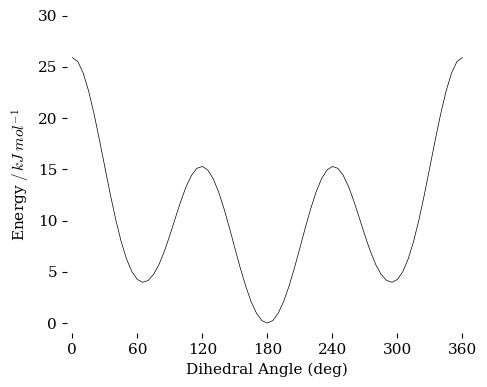

[25.901961913210517, 25.51423851681134, 24.390560023214377, 22.640891014246936, 20.416293398058382, 17.882044635344204, 15.21409183406622, 12.573758797018208, 10.118681582613592, 7.97787782685131, 6.252611542159726, 5.0046453710354335, 4.248934308008901, 3.977713435065619, 4.157168656211354, 4.7490215047804085, 5.717470814338563, 7.0146950049088685, 8.55869580435361, 10.223702914971376, 11.851786817242724, 13.296735660246116, 14.413922757742236, 15.095232104210064, 15.273656186010529, 14.92729392058697, 14.078099100699324, 12.787789754809804, 11.150269802268708, 9.282782318505587, 7.313055394956357, 5.3752623516606866, 3.598960180559323, 2.0937465093643537, 0.9511252690894616, 0.2398007896254434, 0.0, 0.0, 0.2398007896254434, 0.9511252690894616, 2.0937465093643537, 3.598960180559323, 5.3752623516606866, 7.313055394956357, 9.282782318505587, 11.150269802268708, 12.787789754809804, 14.078099100699324, 14.92729392058697, 15.273656186010529, 15.095232104210064, 14.413922757742236, 13.29673

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

styles_location = "../../../styles/"
plt.rcParamsDefault
plt.style.use(styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

df = pd.read_csv(f"{basename}_{runname}.csv")

x1 = df["Dihedral Angle (deg)"].tolist() # change to list for concatenation and other list operations
y1 = df["Energy (kJ/mol)"].tolist()

x = x1 + (np.array(x1)+180).tolist()     # concatenate the original angles with the angles shifted by 180 degrees to create list from 0 to 360 degrees
y = y1 + y1[::-1]                        # concatenate the original energies with the energies in reverse order to match the angles




ax.plot(x, y, marker=None, linewidth=0.5)
ax.set_xlabel("Dihedral Angle (deg)")
ax.set_ylabel(r"Energy $/\,kJ\; mol^{-1}$")
ax.set_xlim(-5, 365)
ax.set(xticks=[0, 60, 120, 180, 240, 300, 360])
ax.set_ylim(-1, 30)
#ax.set(yticks=[0, 5, 10, 15, 20, 25])
#ax.set_title("Butane Rotation Profile")
#plt.grid()
plt.savefig(f"{basename}_{runname}3.pdf", bbox_inches='tight')
plt.show()

print(y)